In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rc('text', usetex = True)

from ast import literal_eval as liteval 
import numpy as np
import os
import math as m
import scipy.optimize as sci

import sys
sys.path.insert(0, os.getcwd().removesuffix("/lane"))
from file_utils import readData, float2latex, bounds
sys.path.pop(0)

dirpath = "//media/ashwin/Expansion/ashwin_md/lane/Aug_Sept2025/Fd100"
figpath = "/home/ashwin/Desktop/ashwin_md/LD/imgs/Aug2025/"

colors = ["darkorange", "olive", "orangered", "crimson", "#2544D0", "goldenrod", "#f57a8e", "#f0384a"]

Average power statistics:

Avg.     : Wext, Qdiss, Qint, Wfluc :  508.209 283.812 85.715 -140.257
Std. dev.: Wext, Qdiss, Qint, Wfluc :  38.16315 12.2738 428.55871 505.05771

Avg.   : (Qdiss + Qint), (Wext + Wfluc) :  369.527 367.952


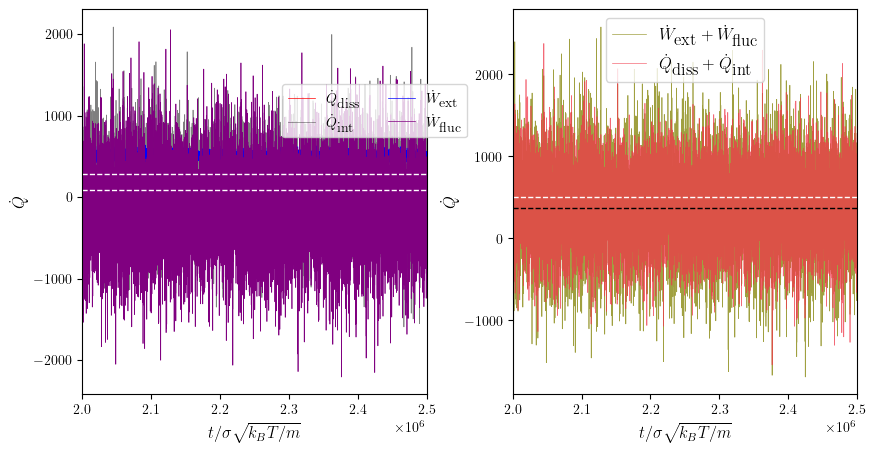

In [29]:
# Plot time series of power statistics

fig, ax = plt.subplots(1, 2, figsize = (10, 5))
lw = 0.5

eq_steps = 1e7
dt = 5e-4
frameStart = 40000
Nevery = 1

# Read time series data
fpath = os.path.join(dirpath, "tau_1e0", "power_x.dat")
[data,_] = readData(fpath, 1)

step = data[0][frameStart::Nevery]
Wext = data[1][frameStart::Nevery]
Qdiss = data[2][frameStart::Nevery]
Qint = data[3][frameStart::Nevery]
Wfluc = data[4][frameStart::Nevery]
time = [(i - eq_steps)*dt for i in step]

# Compute mean and Std. Dev. of the data
Wext_avg = round(sum(Wext)/len(Wext), 3)
Wext_sig = round(m.sqrt(sum([(i - Wext_avg)**2 for i in Wext])/(len(Wext) - 1)), 5)

Qint_avg = round(sum(Qint)/len(Qint), 3)
Qint_sig = round(m.sqrt(sum([(i - Qint_avg)**2 for i in Qint])/(len(Qint) - 1)), 5)

Qdiss_avg = round(sum(Qdiss)/len(Qdiss), 3)
Qdiss_sig = round(m.sqrt(sum([(i - Qdiss_avg)**2 for i in Qdiss])/(len(Qdiss) - 1)), 5)

Wfluc_avg = round(sum(Wfluc)/len(Wfluc), 3)
Wfluc_sig = round(m.sqrt(sum([(i - Wfluc_avg)**2 for i in Wfluc])/(len(Wfluc) - 1)), 5)

sum_diss = [(Qdiss[i] + Qint[i]) for i in range(len(Qdiss))]
sum_work = [(Wext[i] + Wfluc[i]) for i in range(len(Wext))]

sum_diss_avg = round(sum(sum_diss)/len(sum_diss), 3)
sum_work_avg = round(sum(sum_work)/len(sum_work), 3)

# Print the power statistics to screen
print("Average power statistics:\n")
print("Avg.     : Wext, Qdiss, Qint, Wfluc : ", Wext_avg, Qdiss_avg, Qint_avg, Wfluc_avg)
print("Std. dev.: Wext, Qdiss, Qint, Wfluc : ", Wext_sig, Qdiss_sig, Qint_sig, Wfluc_sig)
print("\nAvg.   : (Qdiss + Qint), (Wext + Wfluc) : ", sum_diss_avg, sum_work_avg)

# Plot time series data
ax[0].plot(time, Qdiss, "r-", lw = lw, label = r"$\dot{Q}_{\textrm{diss}}$")
ax[0].plot(time, Qint, "k-", lw = lw, alpha = 0.5, label = r"$\dot{Q}_{\textrm{int}}$")
ax[0].plot(time, Wext, "b-", lw = lw, label = r"$\dot{W}_{\textrm{ext}}$")
ax[0].plot(time, Wfluc, "-", color = "purple", lw = lw, label = r"$\dot{W}_{\textrm{fluc}}$")
ax[1].plot(time, sum_work, "-", color = colors[1], lw = lw, alpha = 0.75, label = r"$\dot{W}_{\textrm{ext}} + \dot{W}_{\textrm{fluc}}$")
ax[1].plot(time, sum_diss, "-", color = colors[7], lw = lw, alpha = 0.75, label = r"$\dot{Q}_{\textrm{diss}} + \dot{Q}_{\textrm{int}}$")

ax[0].axhline(y = Qdiss_avg, xmin = 0, xmax = 1, ls = "--", color = "white", lw = 1)
ax[0].axhline(y = Qint_avg, xmin = 0, xmax = 1, ls = "--", color = "white", lw = 1)
ax[1].axhline(y = Wext_avg, xmin = 0, xmax = 1, ls = "--", color = "white", lw = 1)
ax[1].axhline(y = sum_diss_avg, xmin = 0, xmax = 1, ls = "--", color = "k", lw = 1)

ax[0].set_xlabel(r"$t /\sigma \sqrt{k_BT/m}$", fontsize = 12)
ax[0].set_ylabel(r"$\dot{Q}$", fontsize = 12)
ax[0].set_xlim(min(time), max(time))
ax[0].legend(fontsize = 10, ncols = 2, bbox_to_anchor = (0.56, 0.65))

ax[1].set_xlabel(r"$t /\sigma \sqrt{k_BT/m}$", fontsize = 12)
ax[1].set_ylabel(r"$\dot{Q}$", fontsize = 12)
ax[1].set_xlim(min(time), max(time))
ax[1].legend(fontsize = 12)

# fig.suptitle(r"$F_d^* = 100, ~\tau_{in}^* = 2.0$", fontsize = 15, va = "top")

plt.subplots_adjust(wspace = 0.25)

# fig.savefig(os.path.join(figpath, "power_nr_48.png"), dpi = 500, bbox_inches = "tight")

Total data points = 10000
Run avg. = 30.545843753400003
Population variance = 1050354.259032875
Population std. dev. = 1024.8679227261

1 10000 5000
2 5000 2500
3 2500 1250
4 1250 625
5 624 312
6 312 156
7 156 78
8 78 39
9 38 19
10 18 9
11 8 4
12 4 2

[106.1468614034, 105.1075345088, 106.548400646, 103.30619818, 99.2971565447, 101.4585079811, 97.960426315, 92.9640198614, 101.0734253645, 55.1637490806, 98.896663647, 284.8659962675]

Average variance of sample mean = 97.46098471916667
Average error in mean = 9.8722330158


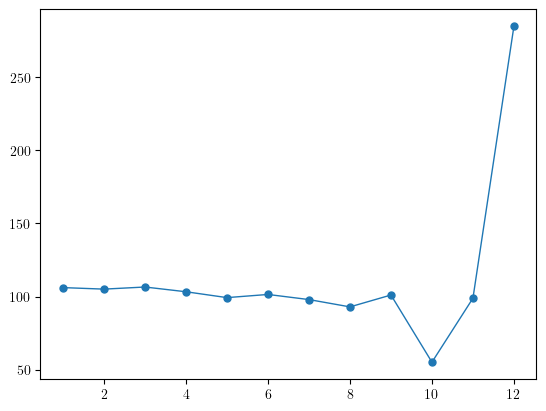

In [50]:
# Compute Standard Error of Mean (SEM) for a time series dataset A

def computeSEM(A):
    if(len(A)%2 == 1):
        A = A[1:]
    
    tau_run = len(A)
    run_avg = sum(A)/tau_run
    run_var = sum([(i - run_avg)**2 for i in A])/(tau_run - 1)

    print("Total data points = {val}".format(val = tau_run))
    print("Run avg. = {val}".format(val = run_avg))
    print("Population variance = {val}".format(val = run_var))
    print("Population std. dev. = {val}\n".format(val = round(np.sqrt(run_var), 10)))

    n_blk = tau_run
    n_trans = 0
    blk_var = []
    
    while(n_blk >= 2):
        new_A = []
        n_blk = int(n_blk/2)

        n_trans += 1    
        
        for i in range(n_blk):
            new_A.append((A[2*i] + A[2*i + 1])/2)
            
        sig2 = 0
        for i in range(n_blk):
            sig2 += (new_A[i] - run_avg)**2
            
        sig2 /= (n_blk*(n_blk - 1))
        blk_var.append(round(sig2, 10))

        print(n_trans, len(A), len(new_A))
        
        if(n_blk%2 == 1):
            index = int(np.random.uniform(0, len(new_A)))
            new_A.pop(index)
            n_blk = int(len(new_A))

        A = new_A
        
        if(n_blk == 2): 
            print("\n{A}".format(A = blk_var))

            fig, ax = plt.subplots()
            ax.plot(np.arange(1, n_trans + 1), blk_var, "o-", ms = 5, lw = 1)
            # ax.set_xlabel("")

            avg_var_mean = sum(blk_var[5:8])/len(blk_var[5:8])
            print("\nAverage variance of sample mean = {val}".format(val = avg_var_mean))
            print("Average error in mean = {val}".format(val = round(np.sqrt(avg_var_mean), 10)))
            break

# dirpath = "/home/ashwin/Desktop/ashwin_md/LD/lmp/tests/sem_analysis"
# fpath = os.path.join(dirpath, "thermo.dat")
# [data, _] = readData(fpath, 1)

# data = data[len(data) - 1]
# data = data[int(0.5*len(data)):]

# computeSEM(Wext)
# computeSEM(Qdiss)
computeSEM(Qint)

-200.0 200.0 50001 4.0 198.3779803547929
-300.0 300.0 50001 6.0 298.33545147297053
-3.0 3.0 50001 0.06 -0.0006968231897338053


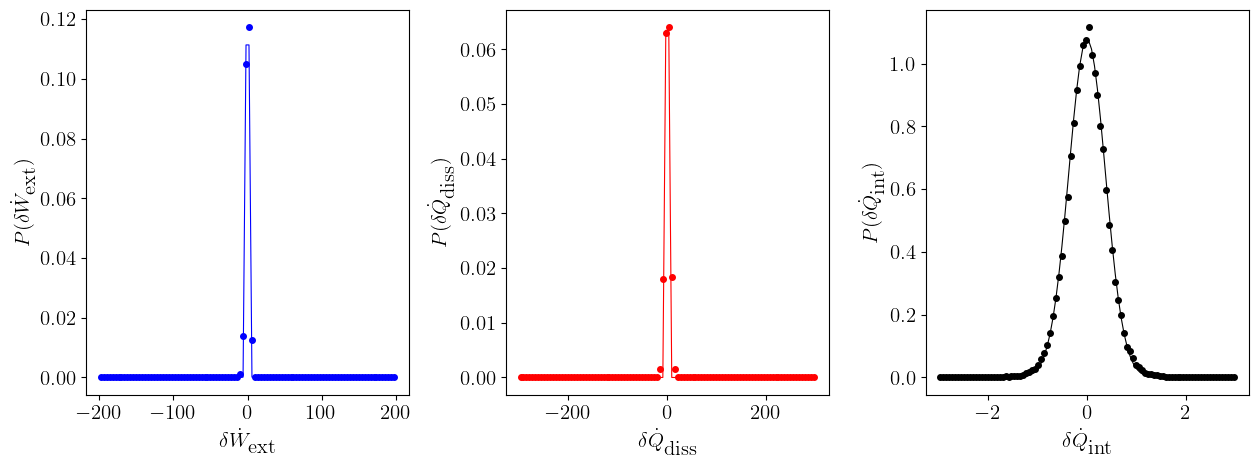

In [32]:
# Plot the distribution of energy rates

def func_gauss(x1, sig):
    return(np.exp(-x1*x1/(2*sig*sig))/np.sqrt(2*m.pi*sig*sig))

color = ["b", "r", "k", "purple"]

nBins = 100
Bins = np.zeros((4, nBins))

fig2, ax2 = plt.subplots(1, 3, figsize = (15, 5))
for i in [1, 2, 3]:
    dataAvg = sum(data[i]) / len(data[i])
    
    data_new = [(j - dataAvg) for j in data[i]]
    
    max_val = max(data_new)
    min_val = min(data_new)

    max_val = bounds(max(abs(max_val), abs(min_val)))

    if(min_val < 0): min_val = -max_val
    else: min_val = 0

    binW = (max_val - min_val)/nBins
    
    print(min_val, max_val, len(data[i]), binW, dataAvg)

    k = i - 1
    for j in range(len(data_new)):
        Bins[k][int((data_new[j] - min_val) / binW)] += 1

    for j in range(len(Bins[k])):
        Bins[k][j] /= (len(data_new) * binW)

    x = [(min_val + (i + 0.5)*binW) for i in range(nBins)]

    popt, _ = sci.curve_fit(func_gauss, x, Bins[k], [1])
    sig2 = popt[0]**2
    
    Px = [m.exp(-val*val/(2*sig2))/m.sqrt(2*m.pi*sig2) for val in x]

    ax2[k].plot(x, Bins[k], "o", color = color[k], ms = 4)
    ax2[k].plot(x, Px, "-", color = color[k], lw = 0.8)

ax2[0].set_xlabel(r"$\delta \dot{W}_{\textrm{ext}}$", fontsize = 15)
ax2[0].set_ylabel(r"$P(\delta \dot{W}_{\textrm{ext}})$", fontsize = 15)
ax2[0].tick_params(axis = "both", which = "major", labelsize = 15)

ax2[1].set_xlabel(r"$\delta \dot{Q}_{\textrm{diss}}$", fontsize = 15)
ax2[1].set_ylabel(r"$P(\delta \dot{Q}_{\textrm{diss}})$", fontsize = 15)
ax2[1].tick_params(axis = "both", which = "major", labelsize = 15)

ax2[2].set_xlabel(r"$\delta \dot{Q}_{\textrm{int}}$", fontsize = 15)
ax2[2].set_ylabel(r"$P(\delta \dot{Q}_{\textrm{int}})$", fontsize = 15)
ax2[2].tick_params(axis = "both", which = "major", labelsize = 15)

plt.subplots_adjust(wspace = 0.3)

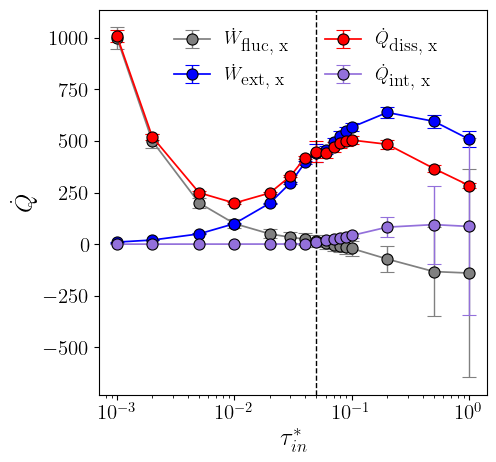

In [9]:
# Plot the average power statistics as a function of inertial time

# Plot params
ms = 8
lw = 1.25
mew = 0.8

# Specify your plots
fig3, ax3 = plt.subplots(1, 1, figsize = (5, 5))

# Read average power data
fpath = os.path.join(dirpath, "avgPower_x.dat")
[data, _] = readData(fpath, 1)

nr = data[0]
tau = data[1]
Wext_avg = data[2]
Qdiss_avg = data[3]
Qint_avg = data[4]
Wfluc_avg = data[5]

Wext_std = data[6]
Qdiss_std = data[7]
Qint_std = data[8]
Wfluc_std = data[9]

# Read kinetic temperature data to compute avg. power input due to brownian fluctuations (Qfluc)
fpath = os.path.join(dirpath, "avgTemp.dat")
[data, _] = readData(fpath, 1)

temp = data[4]
Qdiss_th = [2*temp[i]/tau[i] for i in range(len(tau))]
Wfluc_th = [2/i for i in tau]

"""
# Compute error bars for total dissipated power
sum_diss_avg = []
sum_diss_std = []

for i in range(len(nr)):
    fpath = os.path.join(dirpath, "Data{val}".format(val = nr[i]), "power.dat")
    [data, _] = readData(fpath, 1)

    Qdiss = data[2][frameStart::1]
    Qint = data[3][frameStart::1]

    diss_sum = [(Qdiss[j] + Qint[j]) for j in range(len(Qdiss))]
    sum_diss_avg.append(sum(diss_sum)/len(diss_sum))

    diss_sum_var = [(j - sum_diss_avg[i])**2 for j in diss_sum]
    diss_sum_var = sum(diss_sum_var)
    diss_sum_var /= (len(diss_sum) - 1)
    sum_diss_std.append(np.sqrt(diss_sum_var))

sum_input_avg = [(Qfluc_avg[i] + Wext_avg[i]) for i in range(len(tau))]
diff = [abs(sum_input_avg[i] - sum_diss_avg[i]) for i in range(len(tau))]

for i in range(len(tau)):
    print(tau[i], diff[i])
"""

ax3.errorbar(tau, Wfluc_avg, yerr = Wfluc_std, xerr = None, fmt = "o-", color = "grey", ms = ms, lw = lw, mew = mew, mec = "k",
                ecolor = "grey", elinewidth = 1, capsize = 5, label = r"$\dot{W}_{\textrm{fluc, x}}$")

# ax3.errorbar(tau, Wfluc_th, fmt = "--", color = "grey", ms = ms, lw = lw, mew = mew, mec = "k", label = r"$2k_BT_b/\tau_{in}$")

ax3.errorbar(tau, Wext_avg, yerr = Wext_std, xerr = None, fmt = "bo-", ms = ms, lw = lw, mew = mew, mec = "k",
                ecolor = "b", elinewidth = 1, capsize = 5, label = r"$\dot{W}_{\textrm{ext, x}}$")

ax3.errorbar(tau, Qdiss_avg, yerr = Qdiss_std, xerr = None, fmt = "ro-", mec = "k", mew = mew, ms = ms, lw = lw, 
                ecolor = "r", elinewidth = 1, capsize = 5, label = r"$\dot{Q}_{\textrm{diss, x}}$")

# ax3.errorbar(tau, Qdiss_th, fmt = "--", color = "r", lw = lw, label = r"$2k_BT_{\textrm{eff}}/\tau_{in}$")

ax3.errorbar(tau, Qint_avg, yerr = Qint_std, xerr = None, fmt = "o-", color = "mediumpurple", ms = ms, lw = lw, mew = mew, mec = "k",
               ecolor = "mediumpurple", elinewidth = 1, capsize = 5, label = r"$\dot{Q}_{\textrm{int, x}}$")


# ax3[2].errorbar(tau, sum_input_avg, yerr = Wext_std, xerr = None, fmt = "o-", color = colors[1], ms = ms, lw = lw, mec = "k", mew = mew, 
#               ecolor = colors[1], elinewidth = 1, capsize = 5, label = r"$\dot{W}_{\textrm{ext}} + \dot{W}_{\textrm{fluc}}$")

# ax3[2].errorbar(tau, sum_diss_avg, yerr = sum_diss_std, xerr = None, fmt = "o--", ms = ms, color = colors[7], lw = lw, mec = "k", mew = mew, 
#                 ecolor = colors[7], elinewidth = 1, capsize = 5, label = r"$\dot{Q}_{\textrm{diss}} + \dot{Q}_{\textrm{int}}$")

ax3.axvline(x = 5e-2, ymin = 0, ymax = 1, ls = "--", color = "k", lw = 1)

ax3.set_xlabel(r"$\tau_{in}^*$", fontsize = 18)
ax3.set_ylabel(r"$\dot{Q}$", fontsize = 18)
ax3.tick_params(axis = "both", which = "major", labelsize = 15)
ax3.legend(fontsize = 13, frameon = False, ncols = 2, bbox_to_anchor = (0.15, 0.75))
ax3.set_xscale("log")

# ax3[1].set_xlabel(r"$\tau_{in}^*$", fontsize = 18)
# ax3[1].set_ylabel(r"$\dot{Q}$", labelpad = -15, fontsize = 18)
# ax3[1].tick_params(axis = "both", which = "major", labelsize = 15)
# ax3[1].legend(fontsize = 15, frameon = False)
# ax3[1].set_xscale("log")
# ax3[1].set_title(r"$F_d^* = 100$", pad = 10, fontsize = 18)

plt.subplots_adjust(wspace = 0.3)

# fig3.savefig(os.path.join(figpath, "power_x_Fd100.png"), dpi = 1000, bbox_inches = "tight")